# ALSRS — Model Training Process (Cacao CCN-51)

A step-by-step walkthrough of how we went from the raw dataset to the final
irrigation-need model. Run every cell top to bottom.

## Methodology

1. Load `ml_dataset_cacao_ccn51.csv` and inspect the **zero-inflated** target.
2. **Baseline**: a single Random Forest (split by farm).
3. **Hurdle**: split the problem into "is there a deficit?" + "how much?".
4. **Gate fix**: correct the `P(deficit>0) x magnitude` shrinkage.
5. **Threshold sweep**: choose the gate threshold.
6. **Recall improvement**: cumulative recall + a direct 4-class classifier.
7. **Flexible classification**: merge classes (4 -> 3 -> 2) without retraining.
8. **Cross-validation**: the official metric (5-fold by farm).
9. **Final model**: train on 100% of the data, save, and predict.

## The final decision

| choice | value |
|---|---|
| model | hurdle (classifier + regressor per horizon) |
| gate threshold | 0.5 |
| class scheme | 3 classes: LOW / MODERATE / SEVERE ([15, 50]) |



In [1]:
# -----------------------------------------------------------------------------
# Imports
# -----------------------------------------------------------------------------
%matplotlib inline
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import GroupKFold, train_test_split
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             roc_auc_score, confusion_matrix)

print("pandas", pd.__version__, "| numpy", np.__version__)



pandas 2.3.3 | numpy 2.2.6


In [2]:
# -----------------------------------------------------------------------------
# Dataset + configuration
# -----------------------------------------------------------------------------
ML_DIR = Path.cwd() if Path.cwd().name == "ml" else Path.cwd() / "ml"
DATASET = ML_DIR / "ml_dataset_cacao_ccn51.csv"

df = pd.read_csv(DATASET)
print("Dataset:", DATASET.name, f"({df.shape[0]} rows x {df.shape[1]} cols)")
print("Farms (point_id):", df["point_id"].nunique())

# Features: variables known AT time t only (no future information is leaked).
FEATURES = [
    "month", "biweek",
    "mean_C", "std_C",
    "precip_total_mm", "precip_rainy_days", "pet_mm",
    "spei_1m", "spei_3m", "spei_6m", "spei_12m",
    "AWC_mm", "Storage_mm", "P_acum_mm",
    "WRSI_1m", "deficit_1m",
    "oni",
]

# Targets: deficit accumulated over the NEXT 1 / 3 / 6 months (0-100%).
TARGETS = ["future_deficit_1m", "future_deficit_3m", "future_deficit_6m"]

# Hurdle gate configuration.
DEFICIT_THRESHOLD = 0.0
PROB_THRESHOLD = 0.5

# Classification is a POST-HOC, flexible step (3 classes by default).
CLASS_THRESHOLDS = [15, 50]
CLASS_NAMES = ["LOW", "MODERATE", "SEVERE"]

REGRESSOR_CONFIG = dict(n_estimators=300, max_depth=None, min_samples_leaf=1,
                        random_state=42, n_jobs=-1)
CLASSIFIER_CONFIG = dict(n_estimators=300, max_depth=None, min_samples_leaf=1,
                         class_weight="balanced", random_state=42, n_jobs=-1)



Dataset: ml_dataset_cacao_ccn51.csv (52341 rows x 33 cols)
Farms (point_id): 239


## 1. The problem: a zero-inflated target

The target is the accumulated water deficit. Most of the time there is NO
deficit (value = 0); when there is, it can be very large. A single regressor has
to learn "when" and "how much" at once, which is hard.



In [3]:
for t in TARGETS:
    s = df[t]
    print(f"{t:<24} zeros={(s == 0).mean()*100:5.1f}%  "
          f">0={(s > 0).mean()*100:5.1f}%  max={s.max():6.2f}")



future_deficit_1m        zeros= 72.8%  >0= 27.2%  max=100.00
future_deficit_3m        zeros= 56.4%  >0= 43.6%  max=100.00
future_deficit_6m        zeros= 39.2%  >0= 60.8%  max= 88.84


## 2. Baseline: a single Random Forest

- Split by **farm** (80/20, seed 42): a farm is never in both train and test, so
  we do not leak its time series.
- `sample_weight = deficit` so the model focuses on the rows that actually have
  a deficit (0-deficit rows are ignored).



In [4]:
def weight_linear(d):
    """weight = deficit: zero rows are ignored, the tail dominates."""
    return d


def make_regressor():
    """Fresh RandomForestRegressor with the FINAL configuration."""
    return RandomForestRegressor(**REGRESSOR_CONFIG)


def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


# Split the farms (not the rows) 80/20. -- Validation -- Train/test/val -- 75/15/15
point_ids = df["point_id"].unique()
train_pts, test_pts = train_test_split(point_ids, test_size=0.20, random_state=42)
tr = df[df["point_id"].isin(train_pts)]
te = df[df["point_id"].isin(test_pts)]
print(f"Train farms: {len(train_pts)}  Test farms: {len(test_pts)}")

Xtr = tr[FEATURES].to_numpy()
Xte = te[FEATURES].to_numpy()

# One RF per horizon, trained on ALL rows with linear weight.
base_preds = {}
for t in TARGETS:
    m = make_regressor()
    m.fit(Xtr, tr[t].to_numpy(), sample_weight=weight_linear(tr[t].to_numpy()))
    base_preds[t] = m.predict(Xte)
    print(f"{t:<24} MAE={mean_absolute_error(te[t], base_preds[t]):6.2f}  "
          f"RMSE={rmse(te[t], base_preds[t]):6.2f}")

Train farms: 191  Test farms: 48
future_deficit_1m        MAE= 11.53  RMSE= 14.09
future_deficit_3m        MAE= 10.86  RMSE= 12.85
future_deficit_6m        MAE= 10.66  RMSE= 13.30


## 3. The hurdle (two-stage) model

The literature-standard fix for semicontinuous targets (Cragg 1971, Mullahy 1986,
Lambert 1992) is the **hurdle / two-part model**:

- **Stage 1 (classifier)**: `P(deficit > threshold)` — "is there a deficit?".
- **Stage 2 (regressor)**: trained ONLY on positive rows — "given a deficit, how
  much?".

Each model specializes, instead of one model doing both jobs.



In [5]:
def make_classifier():
    """Fresh RandomForestClassifier with balanced class weights (hurdle stage 1)."""
    return RandomForestClassifier(**CLASSIFIER_CONFIG)


def gated_prediction(p_pos, mu_pos, prob_threshold=PROB_THRESHOLD):
    """Gate: keep the FULL magnitude when P(deficit>0)>=threshold, else 0."""
    return np.where(p_pos >= prob_threshold, mu_pos, 0.0)


def fit_hurdle(X, y, deficit_threshold=DEFICIT_THRESHOLD):
    """Fit stage 1 (classifier) + stage 2 (regressor) for ONE horizon."""
    X = np.asarray(X)
    y = np.asarray(y)
    y_bin = (y > deficit_threshold).astype(int)
    clf = make_classifier()
    clf.fit(X, y_bin)
    pos = y > deficit_threshold
    reg = make_regressor()
    reg.fit(X[pos], y[pos], sample_weight=weight_linear(y[pos]))
    return clf, reg


def hurdle_fit_predict(Xtr, ytr, Xva, deficit_threshold=DEFICIT_THRESHOLD):
    """Fit both stages and return (P>0, magnitude, expected) on Xva."""
    clf, reg = fit_hurdle(Xtr, ytr, deficit_threshold)
    p_pos = clf.predict_proba(np.asarray(Xva))[:, 1]        # p_pos -- Deficit positive probability
    mu_pos = reg.predict(np.asarray(Xva))                   # mu_pos -- Deficit magnitude - mu: Greek letter
    return p_pos, mu_pos, p_pos * mu_pos


def classify_deficit(v, thresholds=CLASS_THRESHOLDS, names=CLASS_NAMES):
    """Map a deficit to a class name (thresholds are configurable)."""
    if pd.isna(v):
        return "NA"
    return names[int(np.searchsorted(thresholds, v, side="left"))]


def bin_vector(v, thresholds):
    """Vectorized: deficit -> class index 0..len(thresholds)."""
    return np.searchsorted(thresholds, np.asarray(v), side="left")


# Fit the hurdle on the same holdout and store the predictions.
hurd_p, hurd_mu, hurd_expected, gated_preds = {}, {}, {}, {}
for t in TARGETS:
    p_pos, mu_pos, expected = hurdle_fit_predict(Xtr, tr[t].to_numpy(), Xte)
    hurd_p[t], hurd_mu[t], hurd_expected[t] = p_pos, mu_pos, expected
    gated_preds[t] = gated_prediction(p_pos, mu_pos)

print("Holdout MAE (all rows): baseline vs hurdle(gated)")
for t in TARGETS:
    b = mean_absolute_error(te[t], base_preds[t])
    g = mean_absolute_error(te[t], gated_preds[t])
    print(f"  {t:<24} baseline={b:6.2f}   hurdle(gated)={g:6.2f}")



Holdout MAE (all rows): baseline vs hurdle(gated)
  future_deficit_1m        baseline= 11.53   hurdle(gated)=  4.36
  future_deficit_3m        baseline= 10.86   hurdle(gated)=  4.94
  future_deficit_6m        baseline= 10.66   hurdle(gated)=  7.38


## 4. The gate: fix the `P x magnitude` shrinkage

If we combine the stages as `expected = P(deficit>0) * magnitude`, the
multiplication by a probability (<1) **shrinks** the magnitude and downgrades the
severe cases. The fix is a **gate**: keep the FULL magnitude when the stage-1
probability is >= 0.5, else predict 0.



In [6]:
def suggestion(preds, thresholds=CLASS_THRESHOLDS, names=CLASS_NAMES):
    """Worst deficit across horizons, binned once (monotonic)."""
    worst = np.maximum(np.maximum(preds[TARGETS[0]], preds[TARGETS[1]]),
                       preds[TARGETS[2]])
    return [names[i] for i in bin_vector(worst, thresholds)]


# True severity = worst true deficit across the 3 horizons.
true_worst = np.maximum(np.maximum(te[TARGETS[0]].to_numpy(), te[TARGETS[1]].to_numpy()),
                        te[TARGETS[2]].to_numpy())
true_sugg = pd.Series(suggestion({t: te[t].to_numpy() for t in TARGETS}), index=te.index)

base_sugg = pd.Series(suggestion(base_preds), index=te.index)
hurd_sugg = pd.Series(suggestion(hurd_expected), index=te.index)   # P * magnitude
gated_sugg = pd.Series(suggestion(gated_preds), index=te.index)    # gate

print("Decision recall (holdout):")
for cls in ["LOW", "MODERATE", "SEVERE"]:
    mask = true_sugg == cls
    b = (base_sugg[mask] == cls).mean()
    h = (hurd_sugg[mask] == cls).mean()
    g = (gated_sugg[mask] == cls).mean()
    print(f"  recall {cls:<10}: baseline={b:.3f}   hurdle(P*mu)={h:.3f}   "
          f"hurdle(gated)={g:.3f}")



Decision recall (holdout):
  recall LOW       : baseline=0.383   hurdle(P*mu)=0.892   hurdle(gated)=0.789
  recall MODERATE  : baseline=0.904   hurdle(P*mu)=0.683   hurdle(gated)=0.831
  recall SEVERE    : baseline=0.664   hurdle(P*mu)=0.565   hurdle(gated)=0.663


## 5. Gate threshold sweep

The gate threshold controls the trade-off: a LOWER threshold -> more "yes"
decisions -> higher recall but more false alarms; a HIGHER threshold -> more
conservative. We sweep it on the binary "needs irrigation" (>= MODERATE)
decision.



 threshold  recall_>=MODERATE  precision  false_alarms
        10              0.958      0.749          1673
        12              0.944      0.772          1448
        15              0.913      0.810          1118
        18              0.864      0.840           859
        20              0.825      0.858           711
        25              0.692      0.901           397


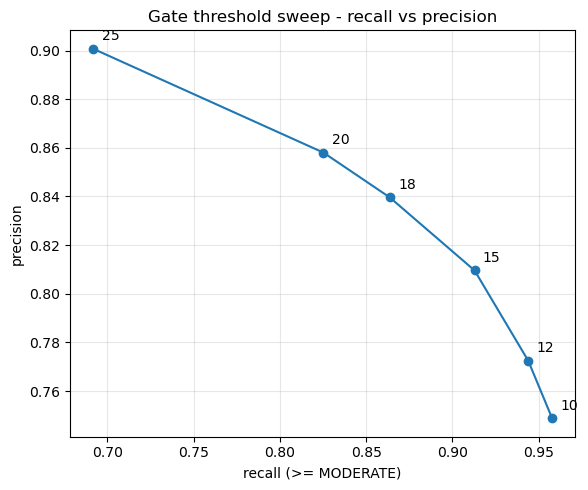

In [7]:
gated_worst = np.maximum(np.maximum(gated_preds[TARGETS[0]], gated_preds[TARGETS[1]]),
                         gated_preds[TARGETS[2]])

# "needs irrigation" = severity >= MODERATE (deficit >= 15).
y_moderate = (true_worst >= 15).astype(int)

rows = []
for thr in [10, 12, 15, 18, 20, 25]:
    pred_moderate = (gated_worst >= thr).astype(int)
    tp = int((pred_moderate & y_moderate).sum())
    fp = int((pred_moderate & (1 - y_moderate)).sum())
    fn = int(((1 - pred_moderate) & y_moderate).sum())
    recall = tp / (tp + fn)
    prec = tp / (tp + fp)
    rows.append([thr, recall, prec, fp])

sw = pd.DataFrame(rows, columns=["threshold", "recall_>=MODERATE", "precision", "false_alarms"])
print(sw.round(3).to_string(index=False))

plt.figure(figsize=(6, 5))
plt.plot(sw["recall_>=MODERATE"], sw["precision"], "o-")
for _, r in sw.iterrows():
    plt.annotate(f"{r['threshold']:.0f}", (r["recall_>=MODERATE"], r["precision"]),
                 textcoords="offset points", xytext=(6, 6))
plt.xlabel("recall (>= MODERATE)")
plt.ylabel("precision")
plt.title("Gate threshold sweep - recall vs precision")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



## 6. Recall improvement

- **Cumulative recall** (`>= MODERATE`, `>= SEVERE`): the decision-relevant
  metric, less strict than exact-class match.
- **Direct 4-class classifier**: an alternative that optimizes classes directly
  (instead of regression -> classify).



In [8]:
# Cumulative recall (decision-relevant).
true_idx = bin_vector(true_worst, CLASS_THRESHOLDS)
gated_idx = bin_vector(gated_worst, CLASS_THRESHOLDS)

print("Cumulative recall (>= level):")
for level, idx in [("MODERATE", 1), ("SEVERE", 2)]:
    m = true_idx >= idx
    print(f"  >= {level:<10}: { (gated_idx[m] >= idx).mean():.3f}")



Cumulative recall (>= level):
  >= MODERATE  : 0.913
  >= SEVERE    : 0.663


In [9]:
# Direct 4-class classifier (for the 4-class scheme) as an alternative.
tr_sugg_4 = suggestion({t: tr[t].to_numpy() for t in TARGETS},
                       thresholds=[15, 30, 50], names=["LOW", "MEDIUM", "HIGH", "NOT_SUITABLE"])
clf4 = RandomForestClassifier(n_estimators=300, max_depth=None, min_samples_leaf=1,
                              class_weight="balanced", random_state=42, n_jobs=-1)
clf4.fit(Xtr, tr_sugg_4)
pred4 = pd.Series(clf4.predict(Xte), index=te.index)

true_sugg_4 = pd.Series(suggestion({t: te[t].to_numpy() for t in TARGETS},
                                   thresholds=[15, 30, 50], names=["LOW", "MEDIUM", "HIGH", "NOT_SUITABLE"]),
                        index=te.index)

gated_sugg_4 = pd.Series(suggestion(gated_preds, thresholds=[15, 30, 50],
                                    names=["LOW", "MEDIUM", "HIGH", "NOT_SUITABLE"]),
                         index=te.index)

print("Exact-class recall (4 classes): hurdle(gated) vs direct classifier")
for cls in ["MEDIUM", "HIGH", "NOT_SUITABLE"]:
    mask = true_sugg_4 == cls
    g = (gated_sugg_4[mask] == cls).mean()
    d = (pred4[mask] == cls).mean()
    print(f"  recall {cls:<13}: hurdle(gated)={g:.3f}   direct4class={d:.3f}")


Exact-class recall (4 classes): hurdle(gated) vs direct classifier
  recall MEDIUM       : hurdle(gated)=0.613   direct4class=0.278
  recall HIGH         : hurdle(gated)=0.456   direct4class=0.450
  recall NOT_SUITABLE : hurdle(gated)=0.663   direct4class=0.822


## 7. Flexible classification: merge classes without retraining

Because the model is **regression**, the class scheme is a post-hoc choice. We
re-bin the SAME continuous predictions into 4, 3 or 2 classes and compare.



In [10]:
SCHEMES = {
    "4_clases":    {"thresholds": [15, 30, 50], "names": ["LOW", "MEDIUM", "HIGH", "NOT_SUITABLE"]},
    "3_clases":    {"thresholds": [15, 50],     "names": ["LOW", "MODERATE", "SEVERE"]},
    "2_clases@20": {"thresholds": [20],         "names": ["MODERATE", "SEVERE"]},
    "2_clases@30": {"thresholds": [30],         "names": ["MODERATE", "SEVERE"]},
}

for name, cfg in SCHEMES.items():
    yt = bin_vector(true_worst, cfg["thresholds"])
    yp = bin_vector(gated_worst, cfg["thresholds"])
    acc = (yt == yp).mean()
    recall = []
    for k in range(len(cfg["names"])):
        m = yt == k
        recall.append((yp[m] == k).mean() if m.sum() else float("nan"))
    print(f"{name:<13} accuracy={acc:.3f}  recall={[round(r, 2) for r in recall]}  {cfg['names']}")



4_clases      accuracy=0.685  recall=[np.float64(0.79), np.float64(0.61), np.float64(0.46), np.float64(0.66)]  ['LOW', 'MEDIUM', 'HIGH', 'NOT_SUITABLE']
3_clases      accuracy=0.779  recall=[np.float64(0.79), np.float64(0.83), np.float64(0.66)]  ['LOW', 'MODERATE', 'SEVERE']
2_clases@20   accuracy=0.854  recall=[np.float64(0.84), np.float64(0.87)]  ['MODERATE', 'SEVERE']
2_clases@30   accuracy=0.862  recall=[np.float64(0.93), np.float64(0.74)]  ['MODERATE', 'SEVERE']


           LOW  MODERATE  SEVERE
LOW       0.79      0.21    0.00
MODERATE  0.13      0.83    0.03
SEVERE    0.01      0.33    0.66


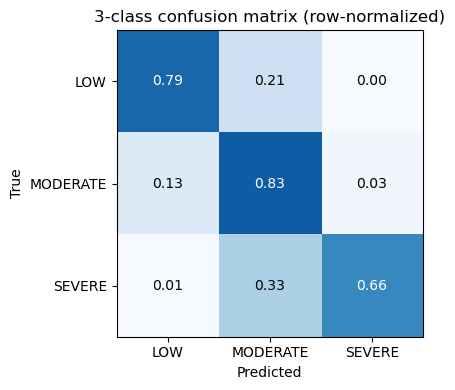

In [11]:
# Row-normalized confusion matrices (diagonal = recall) for the 3-class scheme.
from sklearn.metrics import confusion_matrix as cmf

yt3 = bin_vector(true_worst, [15, 50])
yp3 = bin_vector(gated_worst, [15, 50])
cm3 = cmf(yt3, yp3, labels=[0, 1, 2])
cm3n = cm3 / cm3.sum(axis=1, keepdims=True)
print(pd.DataFrame(cm3n, index=["LOW", "MODERATE", "SEVERE"],
                   columns=["LOW", "MODERATE", "SEVERE"]).round(2).to_string())

plt.figure(figsize=(5, 4))
plt.imshow(cm3n, cmap="Blues", vmin=0, vmax=1)
plt.xticks(range(3), ["LOW", "MODERATE", "SEVERE"])
plt.yticks(range(3), ["LOW", "MODERATE", "SEVERE"])
plt.xlabel("Predicted"); plt.ylabel("True")
for i in range(3):
    for j in range(3):
        plt.text(j, i, f"{cm3n[i, j]:.2f}", ha="center", va="center",
                 color="white" if cm3n[i, j] > 0.5 else "black")
plt.title("3-class confusion matrix (row-normalized)")
plt.tight_layout()
plt.show()



## 8. Cross-validation (official metric)

A single 80/20 holdout is one lucky sample. For the official number we run
5-fold `GroupKFold` grouped by `point_id` (no farm in both train and test).

In [12]:
def cv_compare(target, n_splits=5):
    """5-fold by-farm CV: baseline vs hurdle(gated) MAE/RMSE."""
    gkf = GroupKFold(n_splits=n_splits)
    y = df[target].to_numpy()
    b_mae, b_rmse, h_mae, h_rmse = [], [], [], []
    for tr_idx, va_idx in gkf.split(df, groups=df["point_id"]):
        Xtr_f = df.iloc[tr_idx][FEATURES].to_numpy()
        Xva_f = df.iloc[va_idx][FEATURES].to_numpy()
        ytr = y[tr_idx]
        yva = y[va_idx]

        m = make_regressor()
        m.fit(Xtr_f, ytr, sample_weight=weight_linear(ytr))
        bp = m.predict(Xva_f)
        b_mae.append(mean_absolute_error(yva, bp)); b_rmse.append(rmse(yva, bp))

        p_pos, mu_pos, _ = hurdle_fit_predict(Xtr_f, ytr, Xva_f)
        gp = gated_prediction(p_pos, mu_pos)
        h_mae.append(mean_absolute_error(yva, gp)); h_rmse.append(rmse(yva, gp))

    return (float(np.mean(b_mae)), float(np.mean(b_rmse)),
            float(np.mean(h_mae)), float(np.mean(h_rmse)))


print("5-fold CV by farm:")
for t in TARGETS:
    bm, br, hm, hr = cv_compare(t)
    print(f"  {t:<24} baseline MAE={bm:6.2f} RMSE={br:6.2f}   "
          f"hurdle MAE={hm:6.2f} RMSE={hr:6.2f}")



5-fold CV by farm:
  future_deficit_1m        baseline MAE= 11.24 RMSE= 13.81   hurdle MAE=  4.02 RMSE=  9.59
  future_deficit_3m        baseline MAE= 10.99 RMSE= 12.83   hurdle MAE=  4.64 RMSE=  8.80
  future_deficit_6m        baseline MAE= 10.61 RMSE= 12.81   hurdle MAE=  7.09 RMSE= 10.71


## 9. Final model (100% of data) + predict

Train both stages on EVERY row (deployment model), save with `joblib`, and
expose `predict_hurdle()` with the configurable 3-class binning.



In [13]:
MODEL_DIR = ML_DIR / "hurdle_models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

X_all = df[FEATURES]
models_meta = {}
for t in TARGETS:
    clf, reg = fit_hurdle(X_all, df[t].to_numpy(), DEFICIT_THRESHOLD)
    joblib.dump(clf, MODEL_DIR / f"clf_{t}.joblib")
    joblib.dump(reg, MODEL_DIR / f"reg_{t}.joblib")
    models_meta[t] = {"classifier": f"clf_{t}.joblib", "regressor": f"reg_{t}.joblib"}
    print(f"{t:<24} saved")

manifest = {
    "model_type": "hurdle", "crop": "cacao_ccn51",
    "features": FEATURES, "targets": TARGETS,
    "deficit_threshold": DEFICIT_THRESHOLD, "prob_threshold": PROB_THRESHOLD,
    "class_thresholds": CLASS_THRESHOLDS, "class_names": CLASS_NAMES,
    "classifier_config": CLASSIFIER_CONFIG, "regressor_config": REGRESSOR_CONFIG,
    "models": models_meta,
}
with open(MODEL_DIR / "manifest.json", "w") as fh:
    json.dump(manifest, fh, indent=2)
print("manifest saved")



future_deficit_1m        saved
future_deficit_3m        saved
future_deficit_6m        saved
manifest saved


In [15]:
def predict_hurdle(X, prob_threshold=PROB_THRESHOLD,
                   class_thresholds=CLASS_THRESHOLDS, class_names=CLASS_NAMES):
    """17 features in -> gated deficits + suggestion (configurable classes)."""
    X = np.asarray(X)
    preds = {}
    for t in TARGETS:
        clf = joblib.load(MODEL_DIR / f"clf_{t}.joblib")
        reg = joblib.load(MODEL_DIR / f"reg_{t}.joblib")
        p_pos = clf.predict_proba(X)[:, 1]
        mu_pos = reg.predict(X)
        preds[t] = gated_prediction(p_pos, mu_pos, prob_threshold)

    out = pd.DataFrame(preds)
    worst = out[TARGETS].max(axis=1).to_numpy()
    idx = np.searchsorted(class_thresholds, worst, side="left")
    out["suggestion"] = [class_names[i] for i in idx]
    return out


# Usage example (in-sample sanity check).
demo = predict_hurdle(df[FEATURES].iloc[:10])
print(demo.round(2).to_string())



   future_deficit_1m  future_deficit_3m  future_deficit_6m suggestion
0              65.93              65.10              36.60     SEVERE
1              93.75              67.29              35.22     SEVERE
2              90.52              49.00              28.28     SEVERE
3              68.00              38.34              19.00     SEVERE
4              36.53              23.76              13.58   MODERATE
5              42.02              15.67              10.88   MODERATE
6              32.80              12.75               7.91   MODERATE
7              11.47               4.09               5.53        LOW
8               0.00               0.00               0.00        LOW
9               0.00               0.00               0.00        LOW


## Summary

- **Regression model** predicts the continuous deficit; the class scheme is a
  flexible, post-hoc choice (we adopted 3 classes: LOW / MODERATE / SEVERE).
- **Hurdle** (classifier + regressor per horizon) with the **gate** (threshold
  0.5) matches the baseline on severe-class recall and cuts MAE by ~30-58%.
- **Fewer classes -> higher accuracy** (4 classes 0.69 -> 3 classes 0.78 -> 2
  classes 0.85), because each removed boundary removes the errors that crossed it.
- The final models are saved in `ml/hurdle_models/` with `manifest.json`.

